# Arabic Handwritten Characters Classifier

## Data Loading

In [ ]:
import pandas as pd

train_labels = pd.read_csv('data/labels/train.csv', header=None)
test_labels = pd.read_csv('data/labels/test.csv', header=None)

In [84]:
train_labels.head().values

array([[1],
       [1],
       [1],
       [1],
       [1]])

In [85]:
train_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 13440 entries, 0 to 13439
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       13440 non-null  int64
dtypes: int64(1)
memory usage: 105.1 KB


In [87]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/train',
    labels=train_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 13440 files belonging to 28 classes.
Using 10752 files for training.


In [89]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/train',
    labels=train_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 13440 files belonging to 28 classes.
Using 2688 files for validation.


In [88]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/test',
    labels=test_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 3360 files belonging to 28 classes.


## Visualization

In [81]:
class_names = ['أ', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']

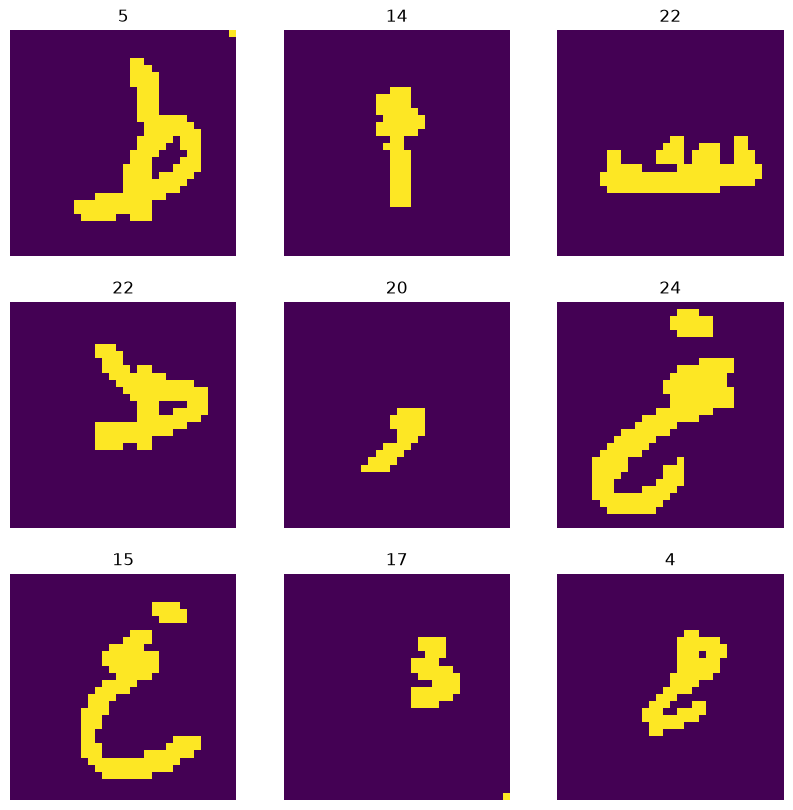

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title((labels[i] - 1).numpy())
        plt.axis("off")

## Data Augmentation

## Training